In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score


In [2]:
digits = load_digits()
cancer = load_breast_cancer()

print("Digits shape:", digits.data.shape)
print("Cancer shape:", cancer.data.shape)


Digits shape: (1797, 64)
Cancer shape: (569, 30)


In [3]:
# MNIST (Multiclass)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42
)

# Breast Cancer (Binary)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

In [4]:
log_bin = LogisticRegression(max_iter=5000)
log_bin.fit(X_train_c, y_train_c)

pred_log_c = log_bin.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_log_c))
print(confusion_matrix(y_test_c, pred_log_c))
print(classification_report(y_test_c, pred_log_c))

Accuracy: 0.9766081871345029
[[ 61   2]
 [  2 106]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [5]:
log_multi = LogisticRegression(max_iter=5000)
log_multi.fit(X_train_d, y_train_d)

pred_log_d = log_multi.predict(X_test_d)

print("Accuracy:", accuracy_score(y_test_d, pred_log_d))

Accuracy: 0.9685185185185186


In [6]:
svm_bin = SVC()
svm_bin.fit(X_train_c, y_train_c)

pred_svm_c = svm_bin.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_svm_c))
print(confusion_matrix(y_test_c, pred_svm_c))


Accuracy: 0.935672514619883
[[ 52  11]
 [  0 108]]


In [7]:
svm_multi = SVC()
svm_multi.fit(X_train_d, y_train_d)

pred_svm_d = svm_multi.predict(X_test_d)

print("Accuracy:", accuracy_score(y_test_d, pred_svm_d))


Accuracy: 0.987037037037037


In [8]:
print("Binary F1 Logistic:", f1_score(y_test_c, pred_log_c))
print("Binary F1 SVM:", f1_score(y_test_c, pred_svm_c))

print("Multiclass F1 Logistic:", f1_score(y_test_d, pred_log_d, average='macro'))
print("Multiclass F1 SVM:", f1_score(y_test_d, pred_svm_d, average='macro'))



Binary F1 Logistic: 0.9814814814814815
Binary F1 SVM: 0.9515418502202643
Multiclass F1 Logistic: 0.9685572781782275
Multiclass F1 SVM: 0.9869102479765148


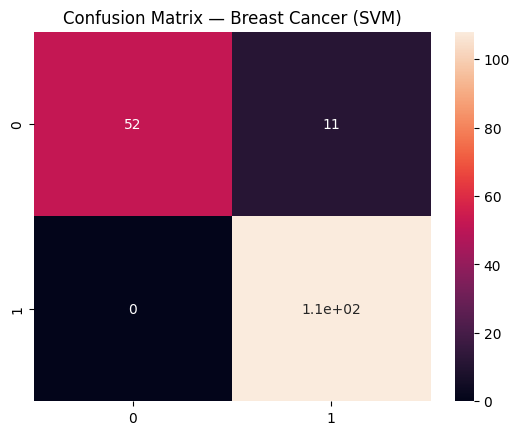

In [9]:
cm = confusion_matrix(y_test_c, pred_svm_c)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix — Breast Cancer (SVM)")
plt.show()


The experiment involved training Logistic Regression and Support Vector Machine (SVM) models on two datasets: the Breast Cancer dataset (binary classification) and the Digits dataset (multiclass classification).

Here's a summary of the evaluation metrics:

Breast Cancer (Binary Classification):

Logistic Regression: Achieved an accuracy of approximately 97.7% and an F1-score of about 98.1%. The confusion matrix showed very few misclassifications (2 false positives and 2 false negatives).
SVM: Achieved an accuracy of about 93.6% and an F1-score of roughly 95.2%. While it had perfect recall for the positive class (0 false negatives), it had 11 false positives for the negative class, as seen in the confusion matrix.
Digits (Multiclass Classification):

Logistic Regression: Achieved an accuracy of approximately 96.9% and a macro-averaged F1-score of about 96.9%.
SVM: Demonstrated slightly better performance with an accuracy of approximately 98.7% and a macro-averaged F1-score of about 98.7%.
In conclusion, both models performed exceptionally well. For the binary classification task (Breast Cancer), Logistic Regression had a slight edge over SVM. However, for the multiclass classification task (Digits), the SVM model showed superior performance.